# 08: Embedding Validation

*Do trained KG embeddings (TransE, RotatE) recover drug–disease links better than topological heuristics and a text-only name prior (EmbeddingGemma)? Uncertainty is reported as resampling-based stability across reruns.*

**Inputs:** `config.yaml` · KG edge files · nb06 checkpoint (heuristic baselines) · committed Gemma metrics
**Outputs:** `results/tables/08_embedding_comparison{,_resampled}.csv` · `results/figures/08_*.{pdf,png}`

## Set-up

In [10]:
# Imports
import sys, os, json, time, math, warnings, pickle
warnings.filterwarnings('ignore')
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import spearmanr

_root = Path(os.path.abspath('')).resolve()
_root = _root.parent if _root.name == 'eval_notebooks' else _root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src.plotting import (setup_style, save_fig, clean_ax,
                           TEXT_COLOR, TICK_COLOR, KG_PALETTE,
                           DOUBLE_COL_W, ROW_H_STD)
from src.loading  import find_config, load_config, load_kg
from src.embedding import (TransE, RotatE, GemmaNameEmbedder,
                           build_train_triples,
                           compute_embedding_metrics)
from src.negative_sampling import generate_negatives

setup_style()

In [12]:
# Config and paths
config   = load_config(find_config(_root))
BASE     = config['_base_dir']
FIGS     = BASE / 'results' / 'figures'
CKPT_DIR = BASE / 'results' / 'checkpoints'
CACHE    = BASE / 'results' / 'cache'
FIGS.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

KG_NAMES  = list(config['knowledge_graphs'].keys())
KG_COLORS = {name: KG_PALETTE.get(name, '#888888') for name in KG_NAMES}

print(f'KGs to evaluate: {KG_NAMES}')

KGs to evaluate: ['primekg', 'hetionet', 'drkg', 'openbilink', 'biokg', 'matrix']


### Hyperparameters

In [13]:
# Embedding hyperparameters
EMB_DIM       = 128
N_EPOCHS      = 100
LR            = 0.01
MARGIN_TRANSE = 1.0
MARGIN_ROTATE = 6.0
BATCH_SIZE    = 512
SEED          = 42
NEG_RATIO     = 5          # negatives per positive (test eval)
MODELS        = ['TransE', 'RotatE']
STRATEGIES    = ['random', 'type-constrained', 'shared-target']

# Per-KG hyperparam overrides. Empty = apples-to-apples (Matrix uses defaults).
PER_KG_OVERRIDES = {}

# Per-KG checkpointing: save every N epochs so a crash resumes mid-run.
CHECKPOINT_KGS    = {'matrix'}   # only Matrix's 8+ hr runs need it
CHECKPOINT_EVERY  = 10

# Per-KG model filter. Empty = all KGs get all models.
# e.g. PER_KG_MODELS = {'matrix': ['TransE']} to skip RotatE for Matrix.
PER_KG_MODELS = {}

def models_for_kg(kg_name):
    return PER_KG_MODELS.get(kg_name, MODELS)

def kg_hyperparams(kg_name):
    base = {'n_epochs': N_EPOCHS, 'dim': EMB_DIM, 'batch_size': BATCH_SIZE}
    base.update(PER_KG_OVERRIDES.get(kg_name, {}))
    return base

print(f'Config: dim={EMB_DIM}, epochs={N_EPOCHS}, lr={LR}, '
      f'batch_size={BATCH_SIZE}, seed={SEED}')
print(f'Models: {MODELS}')
print(f'Neg strategies: {STRATEGIES}')

# Resampling / multi-rerun config
N_RERUNS    = int(os.environ.get('N_RERUNS', 3))
RERUN_SEEDS = [SEED + 1000 * i for i in range(N_RERUNS)]

print(f'Resampling: {N_RERUNS} reruns, seeds = {RERUN_SEEDS}')
print(f'Total fresh trainings: {N_RERUNS} × {len(MODELS)} × {len(KG_NAMES)} = '
      f'{N_RERUNS * len(MODELS) * len(KG_NAMES)}')

Config: dim=128, epochs=100, lr=0.01, batch_size=512, seed=42
Models: ['TransE', 'RotatE']
Neg strategies: ['random', 'type-constrained', 'shared-target']
Resampling: 3 reruns, seeds = [42, 1042, 2042]
Total fresh trainings: 3 × 2 × 6 = 36


## Data preparation

In [14]:
# Free any KG/graph state left over from a previous notebook (prevents
# the ~150 GB OOM that hit when running notebooks back-to-back in one kernel).
for _v in ('kgs', 'graphs', 'maps', 'preps'):
    try:
        del globals()[_v]
    except KeyError:
        pass
import gc
gc.collect()

def prepare_kg_multistrat(kg_name, seed=SEED, neg_ratio=NEG_RATIO):
    """Load KG, split drug-disease edges, generate negatives for all strategies."""
    cache_path = CACHE / f'{kg_name}_prep_multistrat.pkl'
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            data = pickle.load(f)
        if data is not None and 'neg_by_strategy' in data:
            print(f'  {kg_name}: loaded from cache')
            return data

    kg_df, nodes_df = load_kg(kg_name, config)
    kg_cfg = config['knowledge_graphs'][kg_name]
    etypes = kg_cfg['entity_types']
    type_map = dict(zip(nodes_df['idx'], nodes_df['type']))

    drug_idx    = {i for i, t in type_map.items() if t == etypes.get('Drug', 'Drug')}
    disease_idx = {i for i, t in type_map.items() if t == etypes.get('Disease', 'Disease')}
    gene_idx    = {i for i, t in type_map.items() if t == etypes.get('Gene/Protein', 'Gene')}

    dd = kg_cfg.get('relations', {}).get('drug_disease', {})
    ind_rels = [dd['relation']] if 'relation' in dd else dd.get('relations', [])
    dt = kg_cfg.get('relations', {}).get('drug_target', {})
    dt_rels = [dt['relation']] if 'relation' in dt else dt.get('relations', [])

    # Collect drug-disease pairs (vectorised — iterrows on Matrix's
    # 80 M-row kg_df would take hours)
    mask = kg_df['relation'].isin(ind_rels)
    sub = kg_df.loc[mask, ['x_index', 'y_index']].astype('int64')
    h, t = sub['x_index'].values, sub['y_index'].values
    drug_arr    = np.fromiter(drug_idx,    dtype='int64', count=len(drug_idx))
    disease_arr = np.fromiter(disease_idx, dtype='int64', count=len(disease_idx))
    drug_set, disease_set = set(drug_arr.tolist()), set(disease_arr.tolist())
    pairs_set = set()
    fwd_h_in_drug    = np.array([x in drug_set    for x in h])
    fwd_t_in_disease = np.array([x in disease_set for x in t])
    rev_h_in_disease = np.array([x in disease_set for x in h])
    rev_t_in_drug    = np.array([x in drug_set    for x in t])
    fwd_mask = fwd_h_in_drug & fwd_t_in_disease
    rev_mask = rev_h_in_disease & rev_t_in_drug
    pairs_set.update(zip(h[fwd_mask].tolist(), t[fwd_mask].tolist()))
    pairs_set.update(zip(t[rev_mask].tolist(), h[rev_mask].tolist()))
    pairs = list(pairs_set)

    # Train/test split
    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(pairs))
    split = int(0.9 * len(pairs))
    test_pos = [pairs[i] for i in perm[split:]]
    all_pos = set(pairs)

    # Build train triples (all relations, excluding test drug-disease edges)
    train_triples, rel_to_idx, idx_to_rel = build_train_triples(
        kg_df, set(test_pos), ind_rels)
    n_ent = int(nodes_df['idx'].max()) + 1
    node_name_map = dict(zip(nodes_df['idx'], nodes_df['name']))

    # Drug-target map (vectorized — iterrows() on Matrix's drug-target subset
    # is the single largest remaining hotspot in any notebook; this avoids it).
    drug_targets = {}
    dt_mask = kg_df['relation'].isin(dt_rels)
    _dt_sub = kg_df.loc[dt_mask, ['x_index', 'y_index']]
    if not _dt_sub.empty:
        _h = _dt_sub['x_index'].astype('int64').to_numpy()
        _t = _dt_sub['y_index'].astype('int64').to_numpy()
        _gene_arr = np.fromiter(gene_idx, dtype='int64', count=len(gene_idx))
        _h_drug = np.isin(_h, drug_arr)
        _t_gene = np.isin(_t, _gene_arr)
        _h_gene = np.isin(_h, _gene_arr)
        _t_drug = np.isin(_t, drug_arr)
        _fwd = _h_drug & _t_gene
        _rev = _t_drug & _h_gene
        _keep = _fwd | _rev
        _drugs = np.where(_fwd, _h, _t)[_keep]
        _genes = np.where(_fwd, _t, _h)[_keep]
        if _drugs.size:
            _pairs_df = pd.DataFrame({'drug': _drugs, 'gene': _genes})
            drug_targets = {int(d): set(int(x) for x in g)
                            for d, g in _pairs_df.groupby('drug')['gene']}

    # Generate negatives for ALL three strategies
    n_neg = len(test_pos) * neg_ratio
    neg_by_strategy = {}
    for strat in STRATEGIES:
        neg_by_strategy[strat] = generate_negatives(
            test_pos, n_neg, strat, drug_idx, disease_idx,
            drug_targets, node_name_map, all_pos, rng)
        print(f'    {strat}: {len(neg_by_strategy[strat])} negatives')

    rel_idx = rel_to_idx[ind_rels[0]]
    inv_name = f'{ind_rels[0]}_inv'
    rel_idx_inv = rel_to_idx.get(inv_name)

    prep = {
        'train_triples': train_triples, 'rel_to_idx': rel_to_idx,
        'n_ent': n_ent, 'n_rels': len(rel_to_idx),
        'test_pos': test_pos, 'neg_by_strategy': neg_by_strategy,
        'rel_idx': rel_idx, 'rel_idx_inv': rel_idx_inv,
        'n_train': split, 'n_test': len(test_pos),
    }
    with open(cache_path, 'wb') as f:
        pickle.dump(prep, f)
    return prep

# Prepare all KGs
preps = {}
for kg in KG_NAMES:
    print(f'Preparing {kg}...')
    preps[kg] = prepare_kg_multistrat(kg)
    p = preps[kg]
    print(f'  {len(p["train_triples"]):,} train triples, '
          f'{p["n_ent"]:,} entities, {p["n_rels"]} relations, '
          f'{p["n_test"]} test pairs')

Preparing primekg...
  primekg: loaded from cache
  16,197,240 train triples, 129,375 entities, 60 relations, 939 test pairs
Preparing hetionet...
  hetionet: loaded from cache
  4,500,242 train triples, 47,031 entities, 48 relations, 76 test pairs
Preparing drkg...
  drkg: loaded from cache
  11,747,528 train triples, 97,238 entities, 214 relations, 497 test pairs
Preparing openbilink...
  openbilink: loaded from cache
  9,971,608 train triples, 185,929 entities, 56 relations, 717 test pairs
Preparing biokg...
  biokg: loaded from cache
  4,122,622 train triples, 105,524 entities, 34 relations, 6687 test pairs
Preparing matrix...
  matrix: loaded from cache
  83,113,464 train triples, 4,843,934 entities, 152 relations, 38337 test pairs


## Train & evaluate embeddings

In [ ]:
def train_and_evaluate(kg_name, model_name, prep):
    """Train one model on a KG and score it under every negative strategy."""
    print(f'{kg_name}/{model_name}: {len(prep["train_triples"]):,} triples, '
          f'{prep["n_ent"]:,} entities, {prep["n_rels"]} rels', flush=True)

    Cls = TransE if model_name == 'TransE' else RotatE
    hp  = kg_hyperparams(kg_name)                       # per-KG overrides
    kw  = dict(n_entities=prep['n_ent'], n_relations=prep['n_rels'],
               dim=hp['dim'], seed=SEED, lr=LR)
    if model_name == 'RotatE':
        kw['dim'] = max(hp['dim'] // 2, 8); kw['margin'] = MARGIN_ROTATE
    else:
        kw['margin'] = MARGIN_TRANSE

    # Train (large KGs auto-resume from a checkpoint).
    t0 = time.time()
    model = Cls(**kw)
    ckpt_kwargs = {}
    if kg_name in CHECKPOINT_KGS:
        ckpt_path = CACHE / f'embedding_ckpt_{kg_name}_{model_name}.npz'
        ckpt_kwargs = {'checkpoint_path': str(ckpt_path),
                       'checkpoint_every': CHECKPOINT_EVERY}
    model.fit(prep['train_triples'], n_epochs=hp['n_epochs'],
              batch_size=hp['batch_size'], verbose=True, **ckpt_kwargs)
    train_s = time.time() - t0
    print(f'  trained in {train_s:.1f}s', flush=True)

    # Evaluate under each negative-sampling strategy.
    out = {}
    for strat in STRATEGIES:
        m = compute_embedding_metrics(model, prep['test_pos'],
                                      prep['neg_by_strategy'][strat],
                                      prep['rel_idx'], rel_idx_inv=prep['rel_idx_inv'])
        m.update(train_time_s=train_s, n_epochs=hp['n_epochs'],
                 dim=hp['dim'], strategy=strat)
        out[strat] = m
        print(f'  {strat:>18s}: AUROC={m["auroc"]:.4f}  AUPRC={m["auprc"]:.4f}', flush=True)
    return out

In [16]:
# Run all models on all KGs  (cached results are loaded if available)
all_results = {}   # all_results[kg][model][strategy] = metrics dict

for kg in KG_NAMES:
    all_results[kg] = {}
    cache_json = CACHE / f'embedding_{kg}_multistrat.json'

    # Load existing cache if present and hyperparams match
    if cache_json.exists():
        with open(cache_json) as f:
            cached = json.load(f)
        # Check hyperparameter match
        sample = next(iter(next(iter(cached.get('models',{}).values()),{}).values()),{})
        _hp = kg_hyperparams(kg)
        if (sample.get('n_epochs') == _hp['n_epochs'] and
            sample.get('dim')      == _hp['dim']):
            all_results[kg] = cached['models']
            print(f"{kg}: loaded from cache (epochs={_hp['n_epochs']}, dim={_hp['dim']})")
            continue
        else:
            print(f'{kg}: cache hyperparams mismatch, retraining...')

    p = preps[kg]
    for model_name in models_for_kg(kg):
        print(f'\n--- {kg} / {model_name} ---')
        all_results[kg][model_name] = train_and_evaluate(kg, model_name, p)

        # Save AFTER EACH MODEL completes — so a crash on RotatE doesn't
        # lose TransE results (the way it did before).
        out = {'kg': kg, 'models': all_results[kg],
               'n_test': p['n_test'], 'n_entities': p['n_ent'],
               'n_relations': p['n_rels'],
               'n_train_triples': len(p['train_triples'])}
        with open(cache_json, 'w') as f:
            json.dump(out, f, indent=2)
        print(f'  Saved to {cache_json}  (partial: {list(all_results[kg].keys())})')

primekg: loaded from cache (epochs=100, dim=128)
hetionet: loaded from cache (epochs=100, dim=128)
drkg: loaded from cache (epochs=100, dim=128)
openbilink: loaded from cache (epochs=100, dim=128)
biokg: loaded from cache (epochs=100, dim=128)
matrix: loaded from cache (epochs=100, dim=128)


## EmbeddingGemma word-priors baseline

In [17]:
# ── EmbeddingGemma (word-priors) baseline configuration ────────────
# This is intentionally NOT a KG embedding method. It exists to answer:
# "How much of the drug-disease indication signal is latent in a
#  pretrained language model's word priors alone, with ZERO knowledge
#  of the graph?"
#
# The model embeds each entity's bare name (no type prefix, no task prefix,
# no neighborhood context) and scores pairs by cosine similarity.
GEMMA_ENABLED   = True
GEMMA_MODEL     = 'google/embeddinggemma-300m'
GEMMA_DIM       = 768       # 128/256/512/768 (Matryoshka)
GEMMA_BATCH     = 64        # batch size for encoding

# KGs where nodes_df['name'] is human-readable (Gemma's word priors apply).
# DRKG/OpenBioLink/BioKG return opaque ID strings — Gemma will produce
# near-noise on those without external name resolution. We still run them
# (the contrast confirms the hypothesis), but flag them in figures.
GEMMA_NAME_QUALITY = {
    'hetionet':   'readable',
    'primekg':    'readable',
    'drkg':       'id-only',
    'openbilink': 'id-only',
    'biokg':      'id-only',
    'matrix':     'mixed',   # MATRIX has names for most drugs/diseases; gene/pathway IDs vary
}
print(f'Gemma enabled: {GEMMA_ENABLED} | model={GEMMA_MODEL} | dim={GEMMA_DIM}')


Gemma enabled: True | model=google/embeddinggemma-300m | dim=768


In [ ]:
# EmbeddingGemma word-priors baseline.
# Reuse the committed single-run Gemma metrics (tables/08_embedding_comparison.csv)
# rather than re-encoding the gated google/embeddinggemma-300m model. Set
# GEMMA_FORCE_REENCODE = True (and `export HF_TOKEN=...`) to encode for real.
import os
os.environ.setdefault('HF_TOKEN', os.environ.get('HUGGING_FACE_HUB_TOKEN', ''))
GEMMA_FORCE_REENCODE = globals().get('GEMMA_FORCE_REENCODE', False)
gemma_results = {}

_gcsv = BASE / 'results' / 'tables' / '08_embedding_comparison.csv'
if GEMMA_ENABLED and not GEMMA_FORCE_REENCODE and _gcsv.exists():
    _g = pd.read_csv(_gcsv)
    _g = _g[(_g['model'] == 'Gemma') & _g['emb_auroc'].notna()]
    for kg in KG_NAMES:
        per = {}
        for strat in STRATEGIES:
            row = _g[(_g['kg'] == kg) & (_g['strategy'] == strat)]
            if len(row):
                r = row.iloc[0]
                per[strat] = {'auroc': r['emb_auroc'], 'auprc': r.get('emb_auprc'),
                              'mrr': r.get('mrr'), 'hits@10': r.get('hits@10'),
                              'hits@100': r.get('hits@100'),
                              'train_time_s': r.get('train_time_s'), 'dim': GEMMA_DIM,
                              'name_quality': GEMMA_NAME_QUALITY.get(kg, 'unknown')}
        if per:
            gemma_results[kg] = per

if gemma_results:
    print(f'Loaded Gemma results for {len(gemma_results)} KGs from {_gcsv.name} '
          '(set GEMMA_FORCE_REENCODE=True to encode the gated model instead).')
elif not GEMMA_ENABLED:
    print('Gemma disabled (GEMMA_ENABLED = False).')
else:
    # Encode for real — needs the model licence + HF_TOKEN.
    print('No committed Gemma results — encoding (needs HF_TOKEN + model licence).')
    for kg in KG_NAMES:
        p = preps[kg]
        _, nodes_df = load_kg(kg, config)
        name_by_idx = dict(zip(nodes_df['idx'].astype(int), nodes_df['name']))
        names = [name_by_idx.get(i, '') for i in range(p['n_ent'])]
        emb_cache = CACHE / f'gemma_emb_{kg}_d{GEMMA_DIM}.npz'
        model = GemmaNameEmbedder(n_entities=p['n_ent'], n_relations=p['n_rels'],
                                  dim=GEMMA_DIM, model_name=GEMMA_MODEL,
                                  batch_size=GEMMA_BATCH, seed=SEED)
        try:
            if emb_cache.exists():
                model.load_embeddings(emb_cache)
            else:
                model.encode_entities(names); model.save_embeddings(emb_cache)
        except Exception as e:
            print(f'  [skip] {kg}: {type(e).__name__}: {str(e)[:100]}')
            del model; gc.collect(); continue
        per = {}
        for strat in STRATEGIES:
            m = compute_embedding_metrics(model, p['test_pos'],
                                          p['neg_by_strategy'][strat],
                                          p['rel_idx'], rel_idx_inv=None)
            per[strat] = {'auroc': m['auroc'], 'auprc': m['auprc'], 'mrr': m.get('mrr'),
                          'hits@10': m.get('hits@10'), 'hits@100': m.get('hits@100'),
                          'dim': GEMMA_DIM, 'name_quality': GEMMA_NAME_QUALITY.get(kg, 'unknown')}
        gemma_results[kg] = per
        del model; gc.collect()

## Single-run comparison table

In [ ]:
# Single-run comparison table: heuristic baseline (nb06) + trained embeddings + Gemma prior.
_ck06 = pickle.load(open(CKPT_DIR / '06_predictive_performance.pkl', 'rb'))
heur_best = {}   # heur_best[kg][strategy] = best heuristic AUROC (max of AA / CN / Jaccard)
for r in _ck06['link_records']:
    heur_best.setdefault(r['kg'], {}).setdefault(r['strategy'], 0)
    heur_best[r['kg']][r['strategy']] = max(heur_best[r['kg']][r['strategy']], r['auroc'])

def _row(kg, model, strat, m):
    return {'kg': kg, 'model': model, 'strategy': strat,
            'heuristic_auroc': heur_best.get(kg, {}).get(strat),
            'emb_auroc': m.get('auroc'), 'emb_auprc': m.get('auprc'),
            'mrr': m.get('mrr'), 'hits@10': m.get('hits@10'),
            'hits@100': m.get('hits@100'), 'train_time_s': m.get('train_time_s')}

rows  = [_row(kg, mdl, st, all_results[kg].get(mdl, {}).get(st, {}))
         for kg in KG_NAMES for mdl in MODELS for st in STRATEGIES]
rows += [_row(kg, 'Gemma', st, gemma_results.get(kg, {}).get(st, {}))
         for kg in KG_NAMES for st in STRATEGIES]

comp_df = pd.DataFrame(rows)
_out = BASE / 'results' / 'tables' / '08_embedding_comparison.csv'
comp_df.to_csv(_out, index=False)
print(f'Wrote {len(comp_df)} rows ({comp_df.model.nunique()} models × {comp_df.kg.nunique()} KGs) '
      f'to {_out.relative_to(BASE)}')

## Resampling-based stability

Each rerun retrains TransE/RotatE on a fresh random 90/10 split; the figures report mean ± 95% CI across reruns. Skipped automatically when `08_embedding_comparison_resampled.csv` already exists.

In [27]:
# Idempotency guard for the resampling section: if the resampled-results CSV
# already exists, the expensive multi-rerun training + Gemma re-scoring below
# are skipped and the figures load straight from the CSV. Delete the CSV (or
# set RESAMPLED_DONE = False) to force a fresh N-rerun retrain.
RESAMPLED_CSV  = BASE / 'results' / 'tables' / '08_embedding_comparison_resampled.csv'
RESAMPLED_DONE = RESAMPLED_CSV.exists()
print('Resampled CSV found - multi-rerun training/re-scoring will be SKIPPED.'
      if RESAMPLED_DONE else 'No resampled CSV - multi-rerun training WILL run.')

# ── Multi-rerun preparation: different random 10% held out per rerun ──
# Identical to prepare_kg_multistrat but cached per (kg_name, rerun_idx).
# Each rerun's seed perturbs both the test-split and the negative-sampling.

def prepare_kg_resampled(kg_name, rerun_idx, neg_ratio=NEG_RATIO):
    """Like prepare_kg_multistrat but parameterized by rerun_idx."""
    rerun_seed = RERUN_SEEDS[rerun_idx]
    cache_path = CACHE / f'{kg_name}_prep_rerun{rerun_idx}.pkl'
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            data = pickle.load(f)
        if data is not None and 'neg_by_strategy' in data:
            print(f'  {kg_name}/rerun{rerun_idx}: loaded from cache')
            return data

    kg_df, nodes_df = load_kg(kg_name, config)
    kg_cfg = config['knowledge_graphs'][kg_name]
    etypes = kg_cfg['entity_types']
    type_map = dict(zip(nodes_df['idx'], nodes_df['type']))

    drug_idx    = {i for i, t in type_map.items() if t == etypes.get('Drug', 'Drug')}
    disease_idx = {i for i, t in type_map.items() if t == etypes.get('Disease', 'Disease')}
    gene_idx    = {i for i, t in type_map.items() if t == etypes.get('Gene/Protein', 'Gene')}

    dd = kg_cfg.get('relations', {}).get('drug_disease', {})
    ind_rels = [dd['relation']] if 'relation' in dd else dd.get('relations', [])
    dt = kg_cfg.get('relations', {}).get('drug_target', {})
    dt_rels = [dt['relation']] if 'relation' in dt else dt.get('relations', [])

    mask = kg_df['relation'].isin(ind_rels)
    sub  = kg_df.loc[mask, ['x_index', 'y_index']].astype('int64')
    h, t = sub['x_index'].values, sub['y_index'].values
    drug_arr    = np.fromiter(drug_idx, dtype='int64', count=len(drug_idx))
    disease_arr = np.fromiter(disease_idx, dtype='int64', count=len(disease_idx))
    drug_set, disease_set = set(drug_arr.tolist()), set(disease_arr.tolist())
    fwd_h_in_drug    = np.array([x in drug_set    for x in h])
    fwd_t_in_disease = np.array([x in disease_set for x in t])
    rev_h_in_disease = np.array([x in disease_set for x in h])
    rev_t_in_drug    = np.array([x in drug_set    for x in t])
    fwd_mask = fwd_h_in_drug & fwd_t_in_disease
    rev_mask = rev_h_in_disease & rev_t_in_drug
    pairs_set = set()
    pairs_set.update(zip(h[fwd_mask].tolist(), t[fwd_mask].tolist()))
    pairs_set.update(zip(t[rev_mask].tolist(), h[rev_mask].tolist()))
    pairs = list(pairs_set)

    # Train/test split with rerun_seed
    rng = np.random.RandomState(rerun_seed)
    perm = rng.permutation(len(pairs))
    split = int(0.9 * len(pairs))
    test_pos = [pairs[i] for i in perm[split:]]
    all_pos = set(pairs)

    train_triples, rel_to_idx, idx_to_rel = build_train_triples(
        kg_df, set(test_pos), ind_rels)
    n_ent = int(nodes_df['idx'].max()) + 1
    node_name_map = dict(zip(nodes_df['idx'], nodes_df['name']))

    drug_targets = {}
    dt_mask = kg_df['relation'].isin(dt_rels)
    _dt_sub = kg_df.loc[dt_mask, ['x_index', 'y_index']]
    if not _dt_sub.empty:
        _h = _dt_sub['x_index'].astype('int64').to_numpy()
        _t = _dt_sub['y_index'].astype('int64').to_numpy()
        _gene_arr = np.fromiter(gene_idx, dtype='int64', count=len(gene_idx))
        _h_drug = np.isin(_h, drug_arr); _t_gene = np.isin(_t, _gene_arr)
        _h_gene = np.isin(_h, _gene_arr); _t_drug = np.isin(_t, drug_arr)
        _fwd = _h_drug & _t_gene; _rev = _t_drug & _h_gene
        _keep = _fwd | _rev
        _drugs = np.where(_fwd, _h, _t)[_keep]
        _genes = np.where(_fwd, _t, _h)[_keep]
        if _drugs.size:
            _pairs_df = pd.DataFrame({'drug': _drugs, 'gene': _genes})
            drug_targets = {int(d): set(int(x) for x in g)
                            for d, g in _pairs_df.groupby('drug')['gene']}

    n_neg = len(test_pos) * neg_ratio
    neg_by_strategy = {}
    for strat in STRATEGIES:
        neg_by_strategy[strat] = generate_negatives(
            test_pos, n_neg, strat, drug_idx, disease_idx,
            drug_targets, node_name_map, all_pos, rng)

    rel_idx = rel_to_idx[ind_rels[0]]
    inv_name = f'{ind_rels[0]}_inv'
    rel_idx_inv = rel_to_idx.get(inv_name)

    prep = {
        'train_triples': train_triples, 'rel_to_idx': rel_to_idx,
        'n_ent': n_ent, 'n_rels': len(rel_to_idx),
        'test_pos': test_pos, 'neg_by_strategy': neg_by_strategy,
        'rel_idx': rel_idx, 'rel_idx_inv': rel_idx_inv,
        'n_test': len(test_pos),
        'rerun_idx': rerun_idx, 'rerun_seed': rerun_seed,
    }
    with open(cache_path, 'wb') as f:
        pickle.dump(prep, f)
    return prep

print(f'prepare_kg_resampled defined — will produce {N_RERUNS} different '
      f'test splits per KG.')


Resampled CSV found - multi-rerun training/re-scoring will be SKIPPED.
prepare_kg_resampled defined — will produce 3 different test splits per KG.


In [28]:
# Multi-rerun training loop (TransE / RotatE) - the expensive cell.
if RESAMPLED_DONE:
    resampled_results = {}
    print('Resampled CSV present - skipping the multi-rerun training loop.')
else:
    # ── Multi-rerun training loop (TransE / RotatE) — interactive, progress bars ──
    # Fixed-implementation resampling: each rerun trains FRESH from scratch on a
    # different held-out 10% (no checkpoint reuse — that was the old collapse bug).
    # Per-epoch tqdm bar per training + an outer bar over all trainings.
    from tqdm.auto import tqdm
    import time

    # Which KGs to resample. Matrix (~80M triples) is very slow to retrain x N;
    # leave it out for interactive runs, add it back when you have time/budget.
    RESAMPLE_KGS  = [k for k in KG_NAMES if k != 'matrix']   # add 'matrix' to include
    RESAMPLE_BATCH = BATCH_SIZE   # 512 = validated. On GPU raise to 4096+ for speed;
                                  # if the loss stops falling / bounces, lower LR.

    resampled_results = {}
    for kg in RESAMPLE_KGS:
        resampled_results.setdefault(kg, {})
        for mn in MODELS:
            resampled_results[kg].setdefault(mn, {})
            for strat in STRATEGIES:
                resampled_results[kg][mn][strat] = [None] * N_RERUNS

    n_train = sum(len(models_for_kg(kg)) for kg in RESAMPLE_KGS) * N_RERUNS
    outer = tqdm(total=n_train, desc='all trainings', unit='model')
    for kg in RESAMPLE_KGS:
        hp = kg_hyperparams(kg)
        for rerun_idx in range(N_RERUNS):
            p = prepare_kg_resampled(kg, rerun_idx)
            for model_name in models_for_kg(kg):
                Cls = TransE if model_name == 'TransE' else RotatE
                kw = dict(n_entities=p['n_ent'], n_relations=p['n_rels'],
                          dim=hp['dim'], seed=RERUN_SEEDS[rerun_idx], lr=LR)
                if model_name == 'RotatE':
                    kw['dim'] = max(hp['dim'] // 2, 8); kw['margin'] = MARGIN_ROTATE
                else:
                    kw['margin'] = MARGIN_TRANSE
                model = Cls(**kw)
                t0 = time.time()
                for _ in tqdm(range(hp['n_epochs']), leave=False, unit='ep',
                              desc=f'{kg}/{model_name}/rerun{rerun_idx}'):
                    model.fit(p['train_triples'], n_epochs=1,
                              batch_size=RESAMPLE_BATCH, verbose=False)
                train_s = time.time() - t0
                for strat in STRATEGIES:
                    m = compute_embedding_metrics(
                        model, p['test_pos'], p['neg_by_strategy'][strat],
                        p['rel_idx'], rel_idx_inv=p['rel_idx_inv'])
                    m_lite = {k: v for k, v in m.items() if k not in ('scores', 'labels')}
                    m_lite['train_time_s'] = train_s
                    m_lite['rerun_idx']    = rerun_idx
                    m_lite['rerun_seed']   = RERUN_SEEDS[rerun_idx]
                    resampled_results[kg][model_name][strat][rerun_idx] = m_lite
                outer.update(1)
                outer.set_postfix_str(
                    f'{kg}/{model_name} r{rerun_idx} '
                    f'AUROC(tc)={resampled_results[kg][model_name]["type-constrained"][rerun_idx]["auroc"]:.3f}')
    outer.close()
    print(f'Done — {N_RERUNS} reruns x {len(RESAMPLE_KGS)} KGs. '
          f'resampled_results ready for aggregation cell.')


Resampled CSV present - skipping the multi-rerun training loop.


In [29]:
# Gemma re-scoring across reruns.
if RESAMPLED_DONE:
    print('Resampled CSV present - skipping Gemma re-scoring across reruns.')
else:
    # ── Gemma re-scoring across reruns ──────────────────────────────────────
    # Gemma's encoded entity embeddings DON'T change across reruns (entities
    # are the same; only the test-pair selection changes). So we encode once
    # (already cached as gemma_emb_<kg>_d768.npz from the original Gemma run)
    # and just re-score the per-rerun test pairs.
    #
    # This makes Gemma reruns ~100x cheaper than TransE/RotatE reruns.

    if GEMMA_ENABLED:
        print('Re-scoring Gemma across reruns (cheap — embeddings cached)...')
        for kg in KG_NAMES:
            resampled_results[kg].setdefault('Gemma', {})
            for strat in STRATEGIES:
                resampled_results[kg]['Gemma'].setdefault(strat, [])

        for rerun_idx in range(N_RERUNS):
            for kg in KG_NAMES:
                cache_json = CACHE / f'embedding_{kg}_gemma_resampled.json'
                existing = {}
                if cache_json.exists():
                    with open(cache_json) as f:
                        existing = json.load(f)
                done_for_kg = set(existing.get('completed_reruns', []))
                if rerun_idx in done_for_kg:
                    # Pull from cache
                    for strat in STRATEGIES:
                        m = existing.get('results', {}).get(str(rerun_idx), {}).get(strat)
                        if m is not None:
                            slot = resampled_results[kg]['Gemma'][strat]
                            while len(slot) <= rerun_idx:
                                slot.append(None)
                            slot[rerun_idx] = m
                    continue

                p = prepare_kg_resampled(kg, rerun_idx)
                emb_cache = CACHE / f'gemma_emb_{kg}_d{GEMMA_DIM}.npz'
                if not emb_cache.exists():
                    print(f'  {kg}: no Gemma encoding cache — run the original Gemma cell first. Skipping.')
                    continue

                model = GemmaNameEmbedder(n_entities=p['n_ent'], n_relations=p['n_rels'],
                                          dim=GEMMA_DIM, model_name=GEMMA_MODEL,
                                          batch_size=GEMMA_BATCH, seed=SEED)
                model.load_embeddings(emb_cache)

                per_strat = {}
                for strat in STRATEGIES:
                    neg = p['neg_by_strategy'][strat]
                    m = compute_embedding_metrics(model, p['test_pos'], neg,
                                                  p['rel_idx'], rel_idx_inv=None)
                    m_lite = {k: v for k, v in m.items() if k not in ('scores', 'labels')}
                    m_lite['rerun_idx'] = rerun_idx
                    m_lite['rerun_seed'] = RERUN_SEEDS[rerun_idx]
                    m_lite['name_quality'] = GEMMA_NAME_QUALITY.get(kg, 'unknown')
                    per_strat[strat] = m_lite

                    slot = resampled_results[kg]['Gemma'][strat]
                    while len(slot) <= rerun_idx:
                        slot.append(None)
                    slot[rerun_idx] = m_lite

                existing.setdefault('kg', kg)
                existing.setdefault('results', {})
                existing['results'][str(rerun_idx)] = per_strat
                existing.setdefault('completed_reruns', [])
                if rerun_idx not in existing['completed_reruns']:
                    existing['completed_reruns'] = sorted(set(existing['completed_reruns'] + [rerun_idx]))
                existing['gemma_dim'] = GEMMA_DIM
                with open(cache_json, 'w') as f:
                    json.dump(existing, f, indent=2)
                print(f'  {kg}/Gemma/rerun{rerun_idx}: AUROC(tc)={per_strat["type-constrained"]["auroc"]:.4f}')
        print('Gemma re-scoring across reruns complete.')
    else:
        print('Gemma disabled — skipping resampled re-scoring.')


Resampled CSV present - skipping Gemma re-scoring across reruns.


In [30]:
# Aggregation: long-form DataFrame with a `rerun` column.
# If the resampled CSV already exists, load it (skips recompute); otherwise
# build it from the in-memory rerun results and write it out.
if RESAMPLED_DONE:
    resampled_df = pd.read_csv(RESAMPLED_CSV)
    print(f'Loaded {RESAMPLED_CSV.name} from disk - {len(resampled_df)} rows '
          f'({resampled_df["rerun"].nunique()} reruns x '
          f'{resampled_df["kg"].nunique()} KGs x '
          f'{resampled_df["model"].nunique()} models x '
          f'{resampled_df["strategy"].nunique()} strategies)')
else:
    # ── Aggregation: long-form DataFrame with `rerun` column ───────────────
    all_models_resampled = MODELS + (['Gemma'] if GEMMA_ENABLED else [])

    rows_long = []
    for kg in KG_NAMES:
        for model_name in all_models_resampled:
            for strat in STRATEGIES:
                slots = resampled_results.get(kg, {}).get(model_name, {}).get(strat, [])
                for rerun_idx, m in enumerate(slots):
                    if m is None: continue
                    rows_long.append({
                        'kg': kg, 'model': model_name, 'strategy': strat,
                        'rerun': rerun_idx,
                        'rerun_seed': RERUN_SEEDS[rerun_idx],
                        'auroc': m.get('auroc'),
                        'auprc': m.get('auprc'),
                        'mrr': m.get('mrr'),
                        'hits@10': m.get('hits@10'),
                        'hits@100': m.get('hits@100'),
                        'train_time_s': m.get('train_time_s'),
                    })
    resampled_df = pd.DataFrame(rows_long)
    out_csv = BASE / 'results' / 'tables' / '08_embedding_comparison_resampled.csv'
    resampled_df.to_csv(out_csv, index=False)
    print(f'Wrote {out_csv.name} with {len(resampled_df)} rows '
          f'({resampled_df["rerun"].nunique()} reruns × '
          f'{resampled_df["kg"].nunique()} KGs × '
          f'{resampled_df["model"].nunique()} models × '
          f'{resampled_df["strategy"].nunique()} strategies)')

    # Summary: mean ± std across reruns per (kg, model, strategy)
    print('\n=== Summary: mean ± std across reruns (AUROC, type-constrained) ===')
    summary = (resampled_df[resampled_df['strategy'] == 'type-constrained']
               .groupby(['kg', 'model'])['auroc']
               .agg(['mean', 'std', 'min', 'max', 'count'])
               .round(4))
    print(summary.to_string())


Loaded 08_embedding_comparison_resampled.csv from disk - 162 rows (3 reruns x 6 KGs x 3 models x 3 strategies)


## Figures

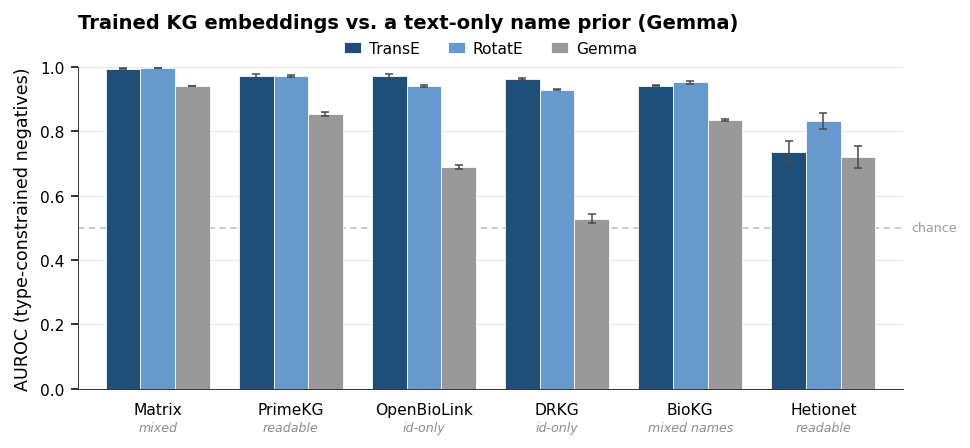

In [ ]:
# ── Publication figure: resampled AUROC (TransE / RotatE / Gemma) ──────
# Mean ± 95% CI across the held-out reruns, type-constrained negatives.
CSV     = BASE / 'results' / 'tables' / '08_embedding_comparison_resampled.csv'
STRAT   = 'type-constrained'
MODELS  = ['TransE', 'RotatE', 'Gemma']
MCOLORS = {'TransE': '#1f4e79', 'RotatE': '#6699cc', 'Gemma': '#999999'}
KG_LABEL = {'primekg': 'PrimeKG', 'hetionet': 'Hetionet', 'drkg': 'DRKG',
            'openbilink': 'OpenBioLink', 'biokg': 'BioKG', 'matrix': 'Matrix'}
NQ = {'primekg': 'readable', 'hetionet': 'readable', 'drkg': 'id-only',
      'openbilink': 'id-only', 'biokg': 'mixed names', 'matrix': 'mixed'}

df = pd.read_csv(CSV)
df = df[df.strategy == STRAT]
models = [m for m in MODELS if m in set(df.model)]

def _stats(kg, m):
    v = df[(df.kg == kg) & (df.model == m)]['auroc'].dropna()
    se = v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0
    return v.mean(), 1.96 * se

kgs = sorted(df.kg.unique(),
             key=lambda k: max(_stats(k, m)[0] for m in models), reverse=True)
x, w = np.arange(len(kgs)), 0.78 / len(models)

fig, ax = plt.subplots(figsize=(7.0, 3.3))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#E8E8E8', lw=0.6, zorder=0)
ax.xaxis.grid(False)
for i, m in enumerate(models):
    means = [_stats(k, m)[0] for k in kgs]
    errs  = [_stats(k, m)[1] for k in kgs]
    ax.bar(x + (i - (len(models) - 1) / 2) * w, means, w,
           color=MCOLORS[m], label=m, edgecolor='white', linewidth=0.4, zorder=2,
           yerr=errs, error_kw=dict(ecolor='#4a4a4a', elinewidth=0.8,
                                    capsize=2, capthick=0.8, zorder=3))
ax.axhline(0.5, color='#BDBDBD', lw=0.8, ls=(0, (4, 3)), zorder=1)
ax.annotate('chance', xy=(1.0, 0.5), xycoords=('axes fraction', 'data'),
            xytext=(4, 0), textcoords='offset points', ha='left', va='center',
            fontsize=6.5, color='#9a9a9a', annotation_clip=False)
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.set_ylabel('AUROC (type-constrained negatives)')
ax.set_xticks(x)
ax.set_xlim(-0.6, len(kgs) - 0.4)
ax.tick_params(bottom=False)
ax.set_xticklabels([KG_LABEL[k] for k in kgs])
for i, k in enumerate(kgs):
    ax.text(i, -0.10, NQ[k], transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=6.5, color='#8C8C8C', style='italic')
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, ncol=len(models), loc='lower center',
          bbox_to_anchor=(0.5, 1.01), handlelength=1.1, handletextpad=0.5,
          columnspacing=1.8, borderpad=0)
ax.set_title('Trained KG embeddings vs. a text-only name prior (Gemma)',
             loc='left', pad=20)
fig.tight_layout()
save_fig(fig, FIGS, '08_resampled_auroc')
plt.show()

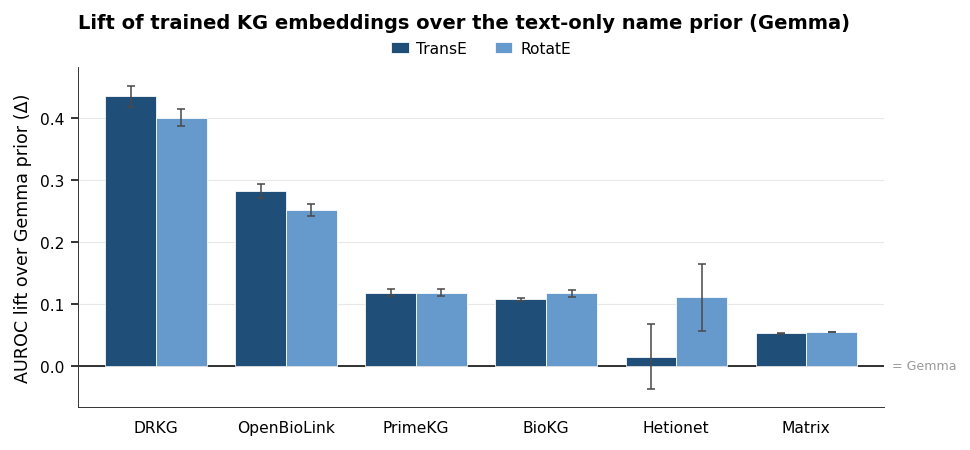

In [ ]:
# ── Publication figure: AUROC lift of trained embeddings over the Gemma prior ──
# Paired Δ(AUROC) per rerun (trained − Gemma), mean ± 95% CI.
TRAINED  = ['TransE', 'RotatE']
BASELINE = 'Gemma'
MCOLORS  = {'TransE': '#1f4e79', 'RotatE': '#6699cc'}

df = pd.read_csv(BASE / 'results' / 'tables' / '08_embedding_comparison_resampled.csv')
df = df[df.strategy == 'type-constrained']
trained = [m for m in TRAINED if m in set(df.model)]
rep_col = 'rerun' if 'rerun' in df.columns else None

def _lift(kg, model):
    """Mean lift (model − Gemma) and 95% CI half-width, paired by rerun when possible."""
    v = df[(df.kg == kg) & (df.model == model)]['auroc'].dropna()
    g = df[(df.kg == kg) & (df.model == BASELINE)]['auroc'].dropna()
    if len(v) == 0 or len(g) == 0:
        return np.nan, 0.0
    if rep_col:
        a = df[(df.kg == kg) & (df.model == model)][[rep_col, 'auroc']]
        b = df[(df.kg == kg) & (df.model == BASELINE)][[rep_col, 'auroc']]
        d = a.merge(b, on=rep_col, suffixes=('_m', '_g'))
        d = (d['auroc_m'] - d['auroc_g']).dropna()
        if len(d) > 1:
            return d.mean(), 1.96 * d.std(ddof=1) / np.sqrt(len(d))
    se_v = v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0
    se_g = g.std(ddof=1) / np.sqrt(len(g)) if len(g) > 1 else 0.0
    return v.mean() - g.mean(), 1.96 * np.sqrt(se_v ** 2 + se_g ** 2)

kgs = [k for k in df.kg.unique()
       if not df[(df.kg == k) & (df.model == BASELINE)].empty
       and any(not df[(df.kg == k) & (df.model == m)].empty for m in trained)]
kgs.sort(key=lambda k: np.nanmean([_lift(k, m)[0] for m in trained]), reverse=True)
x, w = np.arange(len(kgs)), 0.78 / len(trained)

fig, ax = plt.subplots(figsize=(7.0, 3.3))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#E8E8E8', lw=0.6, zorder=0)
ax.xaxis.grid(False)
lows, highs = [], []
for i, m in enumerate(trained):
    means = [_lift(k, m)[0] for k in kgs]
    errs  = [_lift(k, m)[1] for k in kgs]
    lows  += [mu - e for mu, e in zip(means, errs)]
    highs += [mu + e for mu, e in zip(means, errs)]
    ax.bar(x + (i - (len(trained) - 1) / 2) * w, means, w,
           color=MCOLORS[m], label=m, edgecolor='white', linewidth=0.4, zorder=2,
           yerr=errs, error_kw=dict(ecolor='#4a4a4a', elinewidth=0.8,
                                    capsize=2, capthick=0.8, zorder=3))
ax.axhline(0, color='black', lw=0.8, zorder=1)
ax.annotate('= Gemma', xy=(1.0, 0.0), xycoords=('axes fraction', 'data'),
            xytext=(4, 0), textcoords='offset points', ha='left', va='center',
            fontsize=6.5, color='#9a9a9a', annotation_clip=False)
ymin = min(0, min(lows)); ymax = max(highs); pad = 0.06 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)
ax.set_ylabel('AUROC lift over Gemma prior (Δ)')
ax.set_xticks(x)
ax.set_xlim(-0.6, len(kgs) - 0.4)
ax.tick_params(bottom=False)
ax.set_xticklabels([{'primekg': 'PrimeKG', 'hetionet': 'Hetionet', 'drkg': 'DRKG',
                     'openbilink': 'OpenBioLink', 'biokg': 'BioKG',
                     'matrix': 'Matrix'}.get(k, k) for k in kgs])
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, ncol=len(trained), loc='lower center',
          bbox_to_anchor=(0.5, 1.01), handlelength=1.1, handletextpad=0.5,
          columnspacing=1.8, borderpad=0)
ax.set_title('Lift of trained KG embeddings over the text-only name prior (Gemma)',
             loc='left', pad=20)
fig.tight_layout()
save_fig(fig, FIGS, '08_lift_over_gemma')
plt.show()

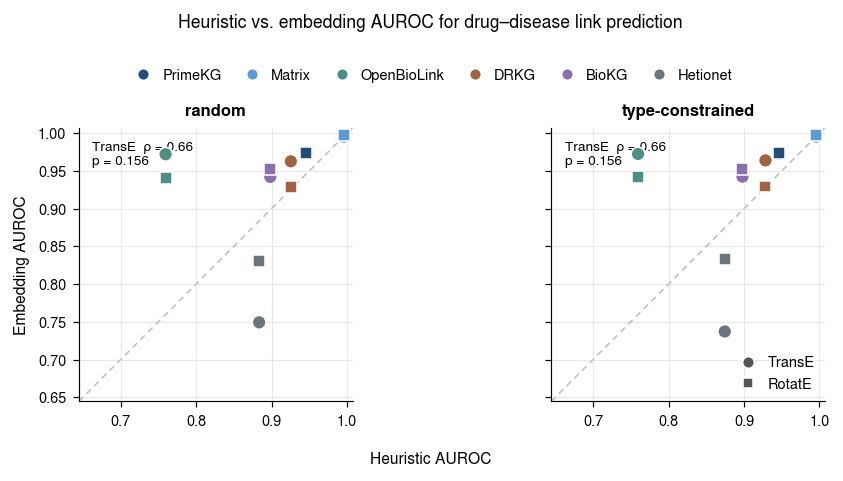

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

# ── Same standard style as the other figures ────────────────────────────────
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Helvetica Neue", "Arial",
                        "Nimbus Sans", "Liberation Sans", "DejaVu Sans"],
    "font.size": 7.5, "axes.titlesize": 8.5, "axes.labelsize": 8,
    "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "legend.fontsize": 7.5,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 3, "ytick.major.size": 3,
    "text.color": "black", "axes.edgecolor": "black",
    "axes.labelcolor": "black", "xtick.color": "black", "ytick.color": "black",
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})

SINGLE = BASE / 'results' / 'tables' / '08_embedding_comparison.csv'   # has heuristic_auroc
RESAMP = BASE / 'results' / 'tables' / '08_embedding_comparison_resampled.csv'   # TransE/RotatE/Gemma (resampled)

KG_LABEL = {"primekg": "PrimeKG", "matrix": "Matrix", "openbilink": "OpenBioLink",
            "drkg": "DRKG", "biokg": "BioKG", "hetionet": "Hetionet"}
# muted, cool-leaning categorical palette: distinct but no bright orange/green
KG_COLORS = {"primekg": "#1f4e79", "matrix": "#5a9bd4", "openbilink": "#4c9085",
             "drkg": "#a0623f", "biokg": "#8a6fae", "hetionet": "#6c757d"}

# ── Build comp_df (heuristic vs embedding AUROC, one row per kg×model×strategy)
sdf = pd.read_csv(SINGLE)
heur = sdf.groupby(["kg", "strategy"])["heuristic_auroc"].first().reset_index()
rdf = pd.read_csv(RESAMP)
emb = (rdf[rdf.model.isin(["TransE", "RotatE"])]
       .groupby(["kg", "model", "strategy"])["auroc"].mean()
       .reset_index().rename(columns={"auroc": "emb_auroc"}))
comp_df = emb.merge(heur, on=["kg", "strategy"], how="inner").dropna()

STRATEGIES = [s for s in ["random", "degree-matched", "type-constrained"]
              if s in set(comp_df.strategy)] or sorted(comp_df.strategy.unique())

# ── Spearman (heuristic vs embedding across KGs) per model×strategy ──────────
rows = []
for m in ["TransE", "RotatE"]:
    for s in STRATEGIES:
        d = comp_df[(comp_df.model == m) & (comp_df.strategy == s)]
        if len(d) >= 3:
            rho, p = spearmanr(d.heuristic_auroc, d.emb_auroc)
            rows.append((m, s, rho, p))
spearman_df = pd.DataFrame(rows, columns=["model", "strategy",
                                          "spearman_rho", "p_value"])

# common square limits so every panel shares one 45 degree identity line
vals = np.r_[comp_df.heuristic_auroc.values, comp_df.emb_auroc.values]
pad = 0.03 * (vals.max() - vals.min())
LO, HI = vals.min() - pad, vals.max() + pad

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(7.4, 3.0), sharey=True)
axes = np.atleast_1d(axes)

for ax_i, strat in enumerate(STRATEGIES):
    ax = axes[ax_i]
    ax.set_axisbelow(True)
    ax.grid(True, color="#E8E8E8", lw=0.6, zorder=0)

    ax.plot([LO, HI], [LO, HI], ls=(0, (4, 3)), color="#BDBDBD", lw=0.8, zorder=1)

    for model_name, marker, ms in [("TransE", "o", 50), ("RotatE", "s", 38)]:
        sub = comp_df[(comp_df.model == model_name) &
                      (comp_df.strategy == strat)].dropna()
        ax.scatter(sub.heuristic_auroc, sub.emb_auroc,
                   c=[KG_COLORS.get(k, "#888") for k in sub.kg],
                   marker=marker, s=ms, zorder=5,
                   edgecolors="white", linewidths=0.8)

    _sr = spearman_df[(spearman_df.model == "TransE") &
                      (spearman_df.strategy == strat)]
    if len(_sr):
        r0 = _sr.iloc[0]
        ax.text(0.05, 0.95,
                f"TransE  \u03c1 = {r0.spearman_rho:.2f}\np = {r0.p_value:.3f}",
                transform=ax.transAxes, fontsize=7, va="top", color="black")

    ax.set_xlim(LO, HI); ax.set_ylim(LO, HI)
    ax.set_aspect("equal", adjustable="box")
    if ax_i == 0:
        ax.set_ylabel("Embedding AUROC")
    ax.set_title(strat, pad=6)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

# model-shape legend in the empty lower-right triangle of the last panel
axes[-1].legend(
    handles=[Line2D([0], [0], marker="o", color="#555", lw=0, ms=6, label="TransE",
                    markeredgecolor="white", markeredgewidth=0.8),
             Line2D([0], [0], marker="s", color="#555", lw=0, ms=5.5, label="RotatE",
                    markeredgecolor="white", markeredgewidth=0.8)],
    frameon=False, loc="lower right", handletextpad=0.4, borderpad=0.2)

# KG colour legend across the top
kg_handles = [Line2D([0], [0], marker="o", color=KG_COLORS[k], lw=0, ms=6,
                     markeredgecolor="white", markeredgewidth=0.8,
                     label=KG_LABEL[k]) for k in KG_LABEL]
fig.legend(handles=kg_handles, frameon=False, ncol=len(kg_handles),
           loc="upper center", bbox_to_anchor=(0.5, 1.0),
           handletextpad=0.3, columnspacing=1.1)

fig.supxlabel("Heuristic AUROC", fontsize=8, y=0.02)
fig.suptitle("Heuristic vs. embedding AUROC for drug\u2013disease link prediction",
             y=1.10)
fig.tight_layout()
save_fig(fig, FIGS, '08_heuristic_vs_embedding_scatter')
plt.show()

In [ ]:
# Memory cleanup - free state before the next notebook.
_to_free = ['kgs', 'graphs', 'maps', 'preps']
for _v in _to_free:
    try:
        del globals()[_v]
    except KeyError:
        pass
import gc
gc.collect()
print('Freed KG state from kernel memory.')

Freed KG state from kernel memory.
